<a href="https://colab.research.google.com/github/gujerlywantgenshin/breast_cancer_classification/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
#importing various packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [100]:
#connecting colab to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
#initializing data
column_names = [
    'id_number',
    'diagnosis',
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave_points_mean',
    'symmetry_mean',
    'fractal_dimension_mean',
    'radius_se',
    'texture_se',
    'perimeter_se',
    'area_se',
    'smoothness_se',
    'compactness_se',
    'concavity_se',
    'concave_points_se',
    'symmetry_se',
    'fractal_dimension_se',
    'radius_worst',
    'texture_worst',
    'perimeter_worst',
    'area_worst',
    'smoothness_worst',
    'compactness_worst',
    'concavity_worst',
    'concave_points_worst',
    'symmetry_worst',
    'fractal_dimension_worst'
]

wdbc_data = pd.read_csv(
    '/content/drive/My Drive/wdbc.data',
    header=None,
    names=column_names
)

display(wdbc_data.head())

,id_number,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [102]:
#splitting the training and test sets – 20% reserved for testing

Y = (wdbc_data['diagnosis'].values == 'M').astype(float)
X = wdbc_data.drop(['id_number', 'diagnosis'], axis=1).values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=21)

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.T
X_test = X_test.T
Y_train = Y_train.reshape(1, -1)
Y_test = Y_test.reshape(1, -1)

In [105]:
def sigmoid(z):
    s = 1/(1 + np.exp(-z))
    return s

In [106]:
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

In [107]:
#initialize params
dim = X_train.shape[0]
w, b = initialize_with_zeros(dim)

assert type(b) == float

In [108]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X)+b)
    cost = -1/m*np.sum(Y*np.log(A)+(1-Y)*np.log(1-A))
    dw = (1/m)*np.dot(X, (A - Y).T)
    db = (1/m)*np.sum(A-Y)
    cost = np.squeeze(np.array(cost))
    grads = {"dw": dw,
             "db": db}

    return grads, cost

In [114]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - learning_rate * dw
        b = b - learning_rate * db
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print ("Cost after iteration %i: %f" %(i, cost))
    params = {"w": w,
              "b": b}
    grads = {"dw": dw,
             "db": db}
    return params, grads, costs

In [118]:
def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)
    A = sigmoid(np.dot(w.T, X)+b)
    for i in range(A.shape[1]):
        if A[0, i] > 0.5 :
            Y_prediction[0,i] = 1
        else:
            Y_prediction[0,i] = 0
    return Y_prediction

In [121]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    w, b = np.zeros((X_train.shape[0], 1)), 0.0
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost=True)
    w = params["w"]
    b = params["b"]
    Y_prediction_test = predict(w,b,X_test)
    Y_prediction_train = predict(w,b,X_train)
    if print_cost:
        print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
        print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    return d

In [120]:
breast_cancer_classification = model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.329849
Cost after iteration 200: 0.249610
Cost after iteration 300: 0.211627
Cost after iteration 400: 0.188629
Cost after iteration 500: 0.172896
Cost after iteration 600: 0.161317
Cost after iteration 700: 0.152369
Cost after iteration 800: 0.145207
Cost after iteration 900: 0.139320
Cost after iteration 1000: 0.134378
Cost after iteration 1100: 0.130159
Cost after iteration 1200: 0.126507
Cost after iteration 1300: 0.123307
Cost after iteration 1400: 0.120475
Cost after iteration 1500: 0.117948
Cost after iteration 1600: 0.115675
Cost after iteration 1700: 0.113617
Cost after iteration 1800: 0.111743
Cost after iteration 1900: 0.110027
train accuracy: 97.36263736263736 %
test accuracy: 98.24561403508773 %


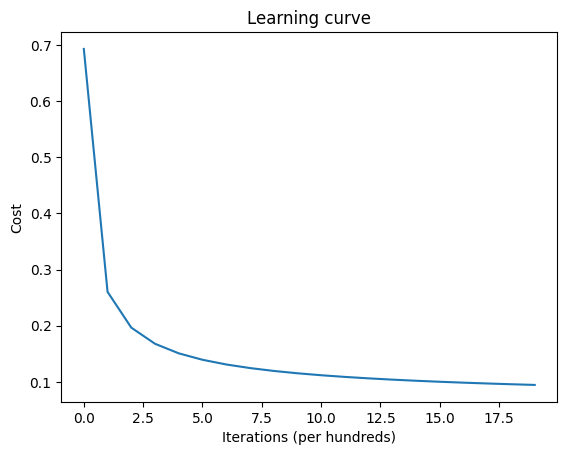

In [122]:
#plotting results
plt.plot(costs)
plt.xlabel('Iterations (per hundreds)')
plt.ylabel('Cost')
plt.title('Learning curve')
plt.show()

<Axes: >

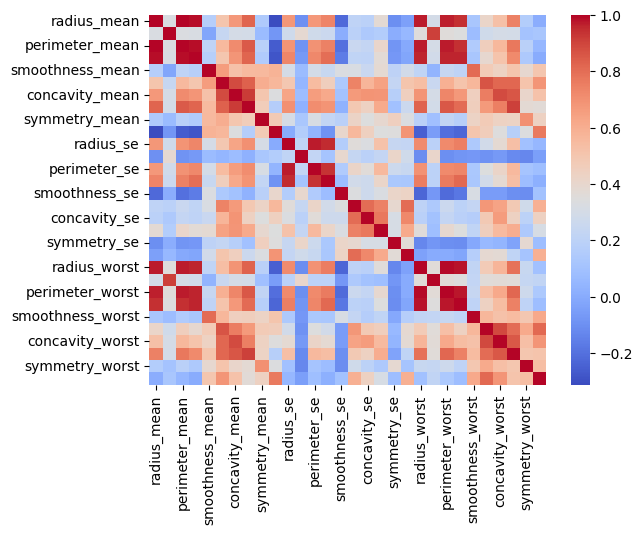

In [126]:
import seaborn as sns
sns.heatmap(wdbc_data.drop(['id_number','diagnosis'], axis=1).corr(), cmap='coolwarm')

<Axes: xlabel='diagnosis', ylabel='radius_mean'>

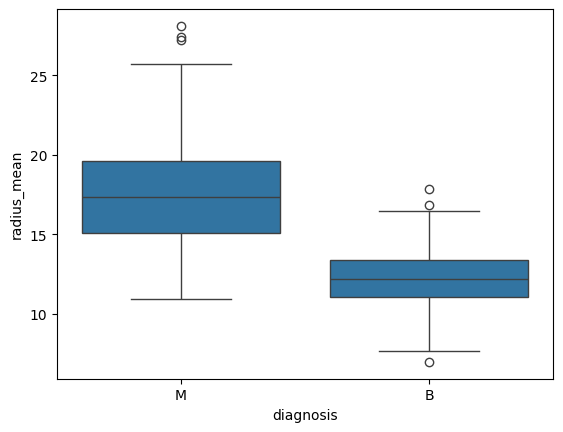

In [127]:
sns.boxplot(x='diagnosis', y='radius_mean', data=wdbc_data)